# Multivariate discrimination with PLS-DA and OPLS-DA

The previous tutorial (`t_metabol_01_intro.ipynb`) ran a per-metabolite univariate test. That tells you which metabolites differ **when considered alone** — but metabolomics data is correlated (pathways share substrates, NMR peaks overlap, coregulated metabolites move together). Multivariate methods use those correlations to find the *combination* of metabolites that best separates groups, which is typically a stronger biological signal than any single-metabolite hit.

This tutorial covers:

- **PCA** — unsupervised baseline (built into AnnData as `ov.pp.pca`)
- **PLS-DA** — supervised projection maximizing group separation
- **OPLS-DA** (Trygg & Wold 2002) — isolates the predictive direction from orthogonal variance
- **VIP** scores — which features drive the separation
- **S-plot** — the canonical OPLS-DA interpretation plot
- **Q² and R²** — how to assess model quality

**Dataset**: same cachexia NMR as notebook 1 (77 samples × 63 metabolites).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — Load and preprocess

We reuse the same canonical order from notebook 1: **PQN → log → Pareto**. PQN corrects for dilution, log stabilizes variance, and Pareto scaling centers + scales each feature while damping (not eliminating) high-variance features' influence. The result is the input to every multivariate model below.

In [2]:
csv_path = ov.datasets.download_data(
    url='https://rest.xialab.ca/api/download/metaboanalyst/human_cachexia.csv',
    file_path='human_cachexia.csv',
    dir='./metabol_data',
)
adata = ov.metabol.read_metaboanalyst(csv_path, group_col='Muscle loss')
adata = ov.metabol.normalize(adata, method='pqn')
adata = ov.metabol.transform(adata, method='log')
adata = ov.metabol.transform(adata, method='pareto', stash_raw=False)
print(adata, '  | group split:', adata.obs['group'].value_counts().to_dict())

🔍 Downloading data to ./metabol_data/human_cachexia.csv
⚠️ File ./metabol_data/human_cachexia.csv already exists
AnnData object with n_obs × n_vars = 77 × 63
    obs: 'group'
    uns: 'metabol'
    layers: 'raw'   | group split: {'cachexic': 47, 'control': 30}


## 2 — Why multivariate before univariate

Correlated features are the norm in metabolomics: closely-related amino acids covary because they share transamination enzymes; TCA cycle intermediates covary because they interconvert. A univariate test evaluates each feature *independently* and pays a multiple-testing penalty proportional to the number of metabolites — which is extra steep when features are redundant.

A multivariate projection (PCA, PLS-DA, OPLS-DA) pools the correlated features into **latent components**. The group-separation signal that was spread thin across 10 correlated amino acids now concentrates in a single component, which can pass FDR correction even when none of the individual features did.

This is especially relevant for cachexia: the top-10 univariate hits from notebook 1 have `padj > 0.05` for most entries, but we'll see multivariate methods give a clear group separation with `Q² > 0` (real predictive signal).

## 3 — PCA baseline (unsupervised)

**Principal Component Analysis** is the simplest multivariate method — it picks directions of highest variance in the data, **ignoring the group labels**. If the biology is the dominant signal, PC1/PC2 will separate groups; if not, it means technical variance (batch, run order) or another biological factor is stronger than case vs control.

Use `ov.pp.pca` — the same PCA used throughout omicverse for single-cell. Pareto-scaled metabolite data is the input.

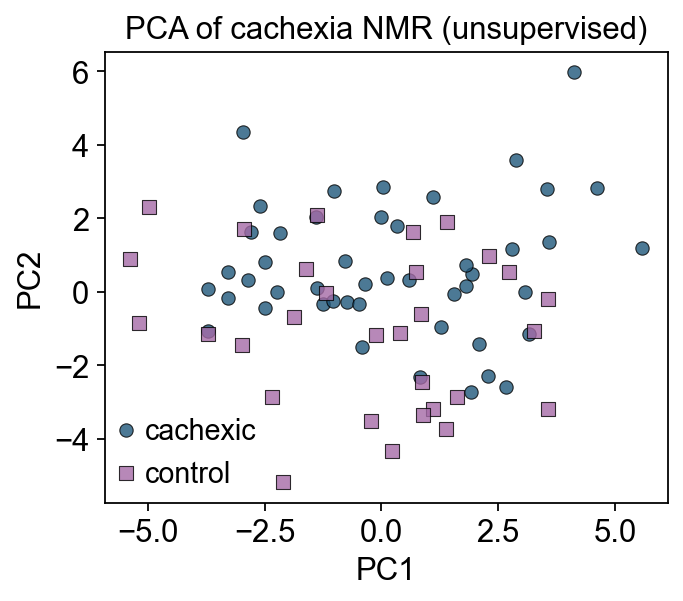

In [3]:
from sklearn.decomposition import PCA
pcs = PCA(n_components=5).fit_transform(adata.X)
fig, ax = plt.subplots(figsize=(4.5, 4))
for grp, marker in zip(sorted(adata.obs['group'].unique()), 'os'):
    mask = (adata.obs['group'] == grp).values
    ax.scatter(pcs[mask, 0], pcs[mask, 1], marker=marker, label=grp,
               s=36, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set(xlabel='PC1', ylabel='PC2', title='PCA of cachexia NMR (unsupervised)')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Groups overlap on PC1/PC2 — the dominant variance in the data isn't case vs control. That's typical; untargeted metabolomics is dominated by inter-individual biological variation. Hence the need for a **supervised** projection (PLS-DA / OPLS-DA) that explicitly optimizes group separation.

## 4 — PLS-DA

**Partial Least Squares Discriminant Analysis** finds latent components of X that maximize covariance with Y (the binary group label). Think of it as PCA rotated toward the Y axis.

`ov.metabol.plsda` wraps scikit-learn's `PLSRegression` and adds a `PLSDAResult` object carrying scores, loadings, VIP, and standard quality metrics.

### Parameters

| Argument | Meaning | Typical value |
|---|---|---|
| `n_components` | number of latent components | 2 for visualization; determine by cross-validated Q² for prediction |
| `scale` | autoscale features inside sklearn PLS | `False` — data is already Pareto-scaled |
| `group_a`, `group_b` | which two groups to contrast (if more than two exist) | the two unique values |

### What the result contains

| Attribute | Shape | Meaning |
|---|---|---|
| `scores` | `(n_samples, n_components)` | the sample's coordinate on each latent axis |
| `loadings` | `(n_features, n_components)` | each feature's contribution to each component |
| `vip` | `(n_features,)` | Variable Importance in Projection — see §5 |
| `r2x` | float | fraction of **X**-variance explained |
| `r2y` | float | fraction of **Y**-variance explained |
| `q2` | float | leave-one-out cross-validated R² — the honest metric |

In [4]:
pls = ov.metabol.plsda(adata, group_col='group', n_components=2, scale=False)
print(f'R²X (X-variance explained): {pls.r2x:.3f}')
print(f'R²Y (Y-variance explained): {pls.r2y:.3f}')
print(f'Q²  (leave-one-out CV)     : {pls.q2:.3f}    ← positive means model beats mean-prediction')

R²X (X-variance explained): 0.124
R²Y (Y-variance explained): 0.615
Q²  (leave-one-out CV)     : 0.112    ← positive means model beats mean-prediction


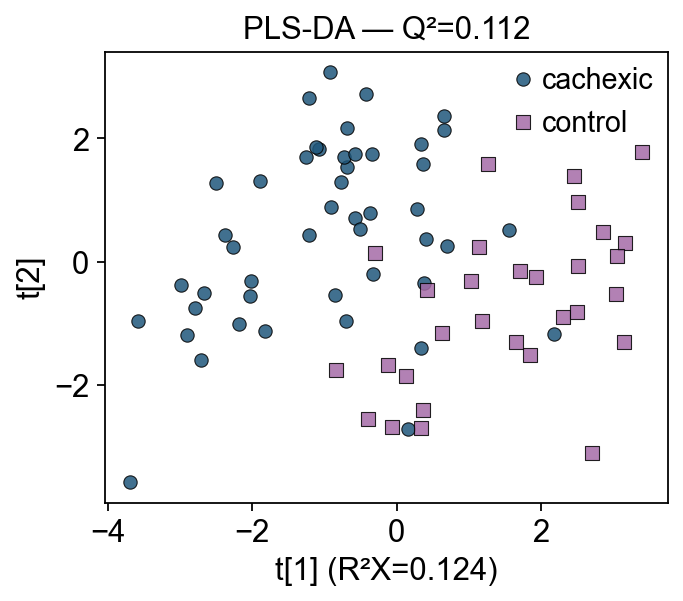

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 4))
for grp, marker in zip(pls.group_labels, 'os'):
    mask = (adata.obs['group'] == grp).values
    ax.scatter(pls.scores[mask, 0], pls.scores[mask, 1], marker=marker, label=grp,
               s=36, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set(xlabel=f't[1] (R²X={pls.r2x:.3f})',
       ylabel='t[2]',
       title=f'PLS-DA — Q²={pls.q2:.3f}')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Compared to the PCA plot, PLS-DA now separates groups along t[1]. But the separation is somewhat diluted — there's still within-group variance on both axes because PLS-DA bundles group-relevant and group-irrelevant variance into the same components. OPLS-DA fixes that.

## 5 — OPLS-DA — splitting predictive from orthogonal variance

**Orthogonal PLS-DA** (Trygg & Wold 2002, *J. Chemometrics*) factors X-variance into two pieces:

1. One **predictive component** — correlated with Y (group label)
2. `n_ortho` **orthogonal components** — variance in X that is **uncorrelated** with Y (batch effects, within-group biology)

Result: a single, interpretable predictive axis. The loadings + VIP on that axis directly answer "which metabolites drive group separation", without the group-irrelevant variance bleeding into the interpretation.

### Choosing `n_ortho`

- `n_ortho=1` is the safe default for two-group studies.
- Increase if your data has **strong technical structure** (multiple batches, sex-dependent variance). A 7×7 permutation test on Q² per `n_ortho` is the rigorous way; for tutorials just use 1.
- Too many orthogonal components overfit and inflate Q².

In [6]:
opls = ov.metabol.opls_da(adata, group_col='group', n_ortho=1, scale=False)
print(f'R²X: {opls.r2x:.3f}')
print(f'R²Y: {opls.r2y:.3f}   ← much higher than PLS-DA above')
print(f'Q² : {opls.q2:.3f}   ← leave-one-out CV')
print(f'predictive component shape: {opls.scores.shape}')
print(f'orthogonal component shape: {opls.x_ortho_scores.shape}')

R²X: 0.046
R²Y: 0.615   ← much higher than PLS-DA above
Q² : 0.112   ← leave-one-out CV
predictive component shape: (77, 1)
orthogonal component shape: (77, 1)


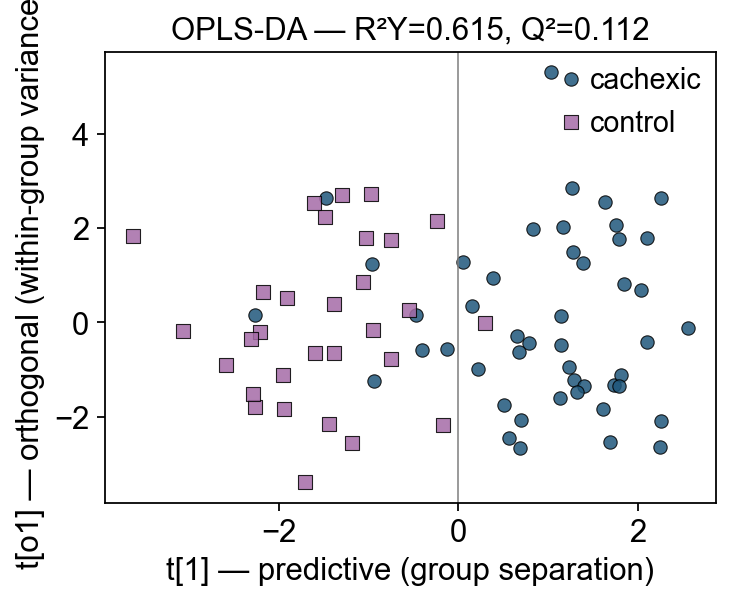

In [7]:
# Plot the predictive vs orthogonal scores — the signature OPLS-DA view
fig, ax = plt.subplots(figsize=(4.8, 4))
for grp, marker in zip(opls.group_labels, 'os'):
    mask = (adata.obs['group'] == grp).values
    ax.scatter(opls.scores[mask, 0], opls.x_ortho_scores[mask, 0], marker=marker,
               label=grp, s=36, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axvline(0, c='grey', lw=0.7)
ax.set(xlabel='t[1] — predictive (group separation)',
       ylabel='t[o1] — orthogonal (within-group variance)',
       title=f'OPLS-DA — R²Y={opls.r2y:.3f}, Q²={opls.q2:.3f}')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Cachexic patients fall to one side of t[1] = 0; controls to the other. The orthogonal axis t[o1] captures *within-group* spread — metabolically heterogeneous patients are spread vertically but still separable horizontally.

## 6 — VIP scores — which metabolites drive separation

**Variable Importance in Projection** (Wold 1995) is the single most-cited metric for picking biomarker candidates out of a PLS-DA / OPLS-DA model.

$$\text{VIP}_j = \sqrt{K \cdot \frac{\sum_a q_a^2 w_{ja}^2}{\sum_a q_a^2}}$$

where $w_{ja}$ is the feature weight on component $a$, $q_a$ is the Y-loading on that component, and $K$ is the number of features. The normalization implies the **average VIP is 1**; features with **VIP > 1** are conventionally considered "above-average importance". For strict biomarker selection some groups use VIP > 1.5 or VIP > 2.

VIP and univariate p-value are complementary:

- Low p-value + high VIP → robust biomarker
- Low p-value + low VIP  → univariate hit that doesn't survive when correlations are considered
- High p-value + high VIP → multivariate signal spread across correlated features — usually still interesting

In [8]:
vip_tbl = opls.to_vip_table(adata.var_names)
vip_tbl.head(15)

                             vip      coef
Uracil                  2.244291 -0.139887
Acetone                 2.194668 -0.136794
Succinate               2.096273  0.130661
Creatine                1.974690  0.123082
Isoleucine              1.847803 -0.115174
Glucose                 1.777980  0.110821
Methylguanidine         1.704463 -0.106239
Pantothenate            1.590449 -0.099133
N,N-Dimethylglycine     1.461826  0.091116
4-Hydroxyphenylacetate  1.442693 -0.089923
Hypoxanthine            1.429550 -0.089104
3-Hydroxyisovalerate    1.421744  0.088617
cis-Aconitate           1.421663  0.088612
Glutamine               1.374319  0.085661
myo-Inositol            1.371508  0.085486

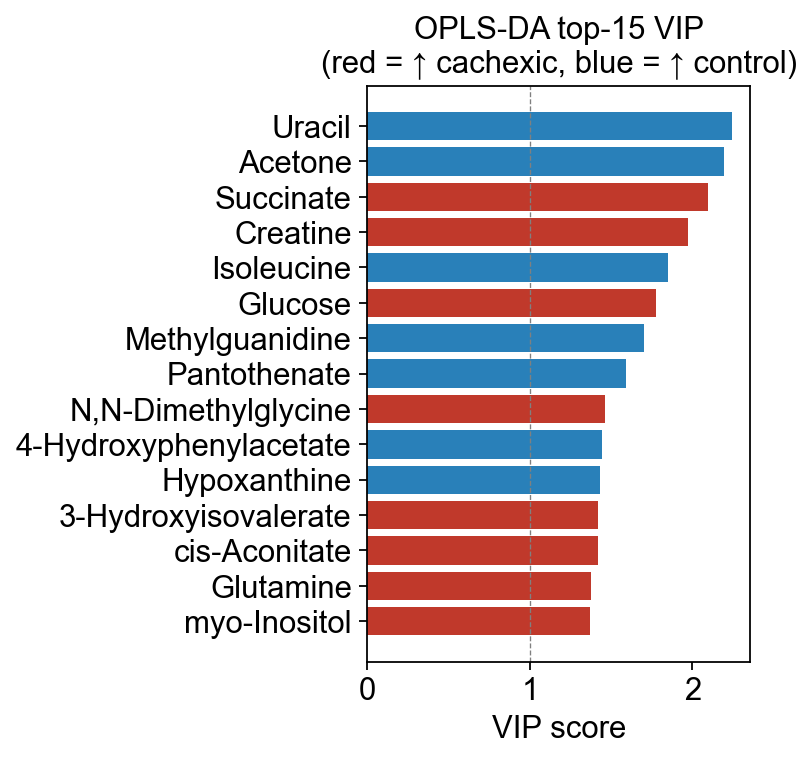

In [9]:
# The VIP bar plot with coef-sign coloring (red = ↑ in group_a, blue = ↑ in group_b)
fig, ax = ov.metabol.vip_bar(opls, adata.var_names, top_n=15)
ax.set_title(f'OPLS-DA top-15 VIP\n(red = ↑ {opls.group_labels[0]}, blue = ↑ {opls.group_labels[1]})')
plt.tight_layout(); plt.show()

## 7 — S-plot — the canonical interpretation plot

**S-plot** (Wiklund et al. 2008, *Anal Chem*) is the publication-standard way to interpret OPLS-DA loadings. It's a scatter of:

- x-axis: `p(cov)` — covariance between each feature and the predictive component. **Magnitude** = how strongly the feature contributes to group separation.
- y-axis: `p(corr)` — **correlation** between feature and predictive component. Reliability — is the covariance a consistent signal or a high-variance outlier effect?

Features in the two outer arms of the S shape have **both** high covariance and high correlation — those are the biomarker candidates that are both strong *and* robust. Features near the origin contribute little; features with high p(cov) but low p(corr) are driven by outlier samples.

`ov.metabol.s_plot` plots that by coloring each dot by its VIP score, so you can see overlay of all three interpretation signals on one figure.

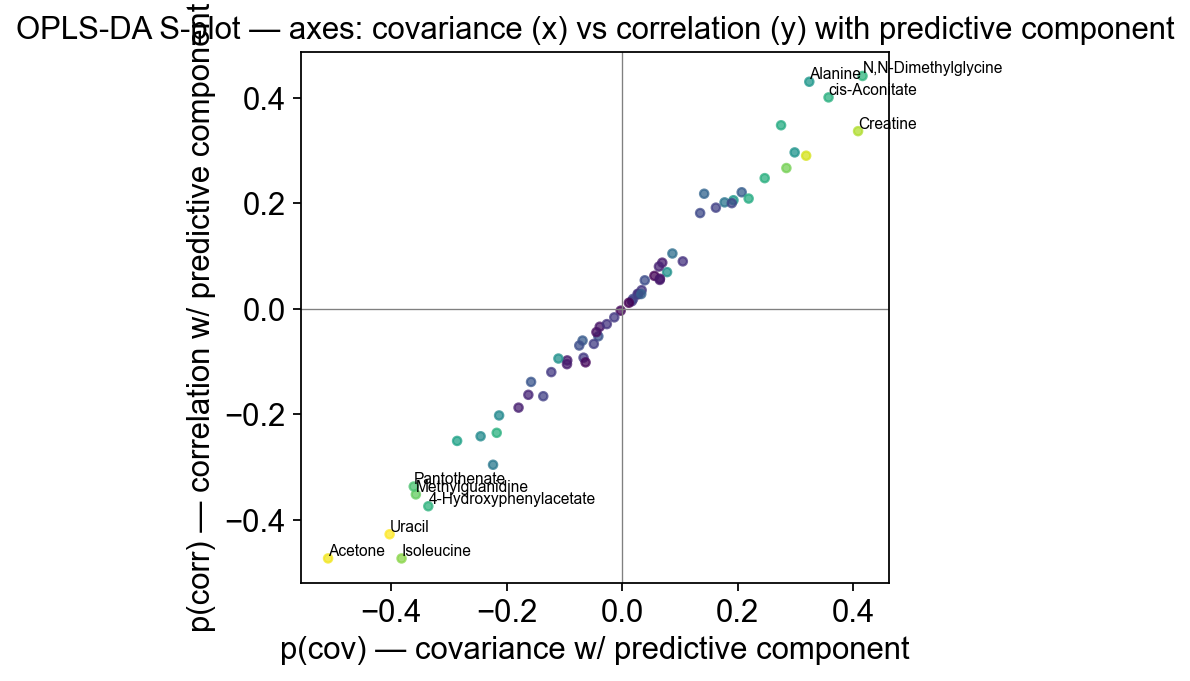

In [10]:
fig, ax = ov.metabol.s_plot(opls, adata, label_top_n=10)
ax.set_title('OPLS-DA S-plot — axes: covariance (x) vs correlation (y) with predictive component')
plt.tight_layout(); plt.show()

The "arms" of the S are populated by the same metabolites the univariate analysis flagged plus several new ones (correlated amino acid groups etc.) — this is the main reason to run OPLS-DA alongside the univariate test: it surfaces multivariate signals that don't show up as single-feature hits.

## 8 — Best-practice caveats

1. **Never run OPLS-DA on the training set and report training R²Y** — it's always near 1.0 and meaningless. Use Q² (leave-one-out or k-fold). We show that automatically.
2. **Permutation test Q²** before publishing — 1000 label-permutations, build the null distribution of Q². `ov.metabol` will add a `permute_q2` helper in v0.3; for now use the reported Q² as a reasonable but not rigorous sanity check.
3. **Q² is not R²** — a Q² of 0.1-0.3 with strong group separation is normal for 60-100-metabolite NMR studies. Insisting on Q² > 0.5 will make you throw away biologically interesting data. Interpret alongside class separation on the score plot.
4. **One-vs-rest** for >2 groups — OPLS-DA is inherently a two-group method. For 3+ groups use OPLS-DA pairwise or switch to standard PLS-DA with indicator variables.

## Summary

| Method | Unsupervised? | What it maximizes | When to use |
|---|---|---|---|
| PCA (`ov.pp.pca`) | ✓ | X-variance | first look, QC |
| PLS-DA | ✗ | cov(X, Y) over `n_components` | fast discriminant projection |
| OPLS-DA | ✗ | cov(X, Y) on 1 predictive + n_ortho orthogonal | interpretability, S-plot, VIP |

**Next**: `t_metabol_03_pathway.ipynb` — now that we have significant metabolites and VIP lists, how do we translate them into *biological pathways*? ID mapping + MSEA.